## Data correction

This notebook helps preparing data obtained from pyridine adsorption IR measurements for further evaluation. The data is extracted from the measurement files, corrected, truncated and saved to new csv files.
The baseline correction is done with the measurement data of the unloaded sample ("_hydrated_"). As only the ring breathing vibrations in the range of 1400 cm$^{-1}$ < $\nu$ < 1600 cm$^{-1}$ are of interest, the data is truncated accordingly.

***

First of all, import all needed packages.

In [1]:
from pathlib import Path

from modules.data_processer import IRDataHandler
from modules.peak_fitter import PeakFitter, FitConfig


print("All done.")

All done.


---
In your current working directory (`cwd`), specify the `folder` containing the data which are to be processed. The list of available files gives an overview over all samples in this specific folder.

In [2]:
# Setup paths and configuration
folder = "PyrIR_OMAS_1-80_T80_AKS11"
cwd = Path.cwd()
path_to_directory = cwd / folder
print(path_to_directory)
# Initialize data handler
data_handling = IRDataHandler(path_to_directory=path_to_directory, folder = folder, decimal=",")
data_handling.available_files()

d:\Dokumente\01_Projects\02_Silica Materials\07_Manuscripts\Ott et al. 2024\data4DaRUS\Pyridin_FTIR - Kopie\PyrIR_OMAS_1-80_T80_AKS11


{0: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_300C',
 1: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_350C',
 2: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_400C',
 3: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_450C',
 4: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_150C',
 5: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_200C',
 6: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_250C',
 7: 'PyrIR_OMAS_1-80_T80_x300min_450C_background'}

---
You can plot all measurement data into one figure for both comparison and publication.
The legend can be extracted from the respective characters in the file name. `val1` gives the first chracter, `val2` the last.

Adding measurement 150 °C to figure.
Adding measurement 200 °C to figure.
Adding measurement 250 °C to figure.
Adding measurement 300 °C to figure.
Adding measurement 350 °C to figure.
Adding measurement 400 °C to figure.
Adding measurement 450 °C to figure.


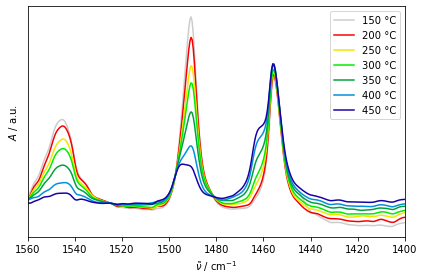

In [3]:
# Process and plot data
data_handling.get_plot()

If the plots are satisfactory, you can save your corrected data to new csv files with the following command.

In [4]:
data_handling.save_data_to_csv()

In [4]:
# Save metadata
data_handling.add_sample_metadata(
    sample_mass = 0.1072,
    sample_length = 2.015,
    sample_width= 1.013,
    extinction_coefficient_bronsted=2.22,
    extinction_coefficient_lewis=1.67,
    error_sample_length=0.001,
    error_sample_width=0.001,
    error_sample_mass=0.0001,
    surface_area=351.0, # OPTIONAL: surface area in m²/g
    error_surface_area=None,# OPTIONAL: error in surface area
)
data_handling.save_json(json_filename=f"{folder}.json")

Data saved to PyrIR_OMAS_1-80_T80_AKS11.json


***

## Gaussian Fitting

This notebook can fit two or three peaks in your respective Pyridine-adsorption IR spectra with a Gaussian. With the fitting parameters obtained from the fits, the number of active sites corresponding to Bronsted and/or Lewis sites can be calculated from

$N = \frac{S_{area} \cdot A_{peak}}{m_{sample} \cdot \varepsilon}$

With the sample area $S_{area}$, or area of the sample wafer, the sample mass $m_{sample}$, the absorption coeffiecient $\varepsilon$ of the investigated material and the peak area $A_{peak}$ which is obtained from the fitting parameters.

The calculated results can be saven to a TXT file.

Specify the folder `corr` which holds the corrected data which is to be fitted. 

In [5]:
# Setup peak fitiing
corr = Path(folder) / "corr"

# Create fit configuration
fit_config = FitConfig(
    threshold=0.01
)

# Initialize PeakFitter
peak_fitter = PeakFitter(
    path_to_directory= cwd / corr,
    folder=corr,
    fit_config=fit_config
)
# Print available files
peak_fitter.available_files()


{0: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_300C_corr',
 1: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_350C_corr',
 2: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_400C_corr',
 3: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_30min_450C_corr',
 4: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_150C_corr',
 5: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_200C_corr',
 6: 'PyrIR_OMAS_1-80_T80_360min_450C_30min_4mbar_Pyr_60min_250C_corr'}

From the list above, choose a file by its index, which you would like to fit. The control plot shows, if all peaks that should be fitted are found. If peaks are missing or too many peaks are found by the algorithm, adjust the threshold value accordingly. Define a `name` which will be the file name of the saved plot. To control if all important peaks are found, check the control plot:


Adding sample metadata...
Current results keys: ['sample_metadata', 'lewis', 'mixed', 'bronsted', 'number_acid_sites', 'site_density', 'umol_per_nm2']
Stored sample metadata in results dictionary
Updated results keys: ['sample_metadata', 'lewis', 'mixed', 'bronsted', 'number_acid_sites', 'site_density', 'umol_per_nm2']
Sample metadata keys: ['mass', 'length', 'width', 'extinction_coefficient', 'surface_area']

Sample metadata added successfully:
Mass: 0.1072 g
Length: 2.015 cm
Width: 1.013 cm
Extinction coefficient (Bronsted): 2.22 mmol cm^-2
Extinction coefficient (Lewis): 1.67 mmol cm^-2
Surface area: 351.0 m²/g
Successfully loaded metadata from d:\Dokumente\01_Projects\02_Silica Materials\07_Manuscripts\Ott et al. 2024\data4DaRUS\Pyridin_FTIR - Kopie\PyrIR_OMAS_1-80_T80_AKS11.json


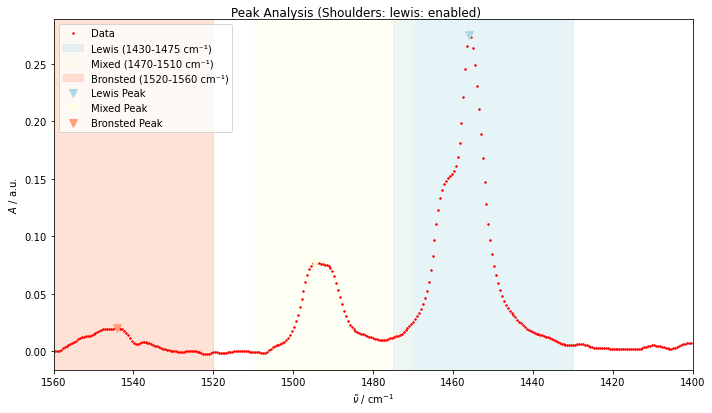

In [30]:
# Add sample meta data
path_to_json = cwd / folder
peak_fitter.load_metadata_from_json(f"{path_to_json}.json")

# Extract data and find peaks
index = 3
name=f"{corr}_{index}"
peak_fitter.extract_data(index=index)
peak_fitter.get_control_plot(index=index)

Shoulder fitting for lewis region enabled
Starting analysis...
Available regions: ['lewis', 'mixed', 'bronsted']
Preserved existing sample metadata

Analyzing lewis region...
Wavenumber range: 1430 - 1475 cm⁻¹
Found 93 data points in range
Attempt 1/20: Using shoulder fit for lewis region
Attempt 2/20: Using shoulder fit for lewis region
Fit successful with acceptable residuals after 2 attempts
Fit successful - Area: 2.6753, Shoulder: True, Error: 0.0017

Analyzing mixed region...
Wavenumber range: 1470 - 1510 cm⁻¹
Found 83 data points in range
Attempt 1/20: Using single Voigt fit for mixed region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 1.0223, Shoulder: False, Error: 0.0054

Analyzing bronsted region...
Wavenumber range: 1520 - 1560 cm⁻¹
Found 83 data points in range
Attempt 1/20: Using single Voigt fit for bronsted region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 0.2913, Shoulder: False, Error: 0.0011

An

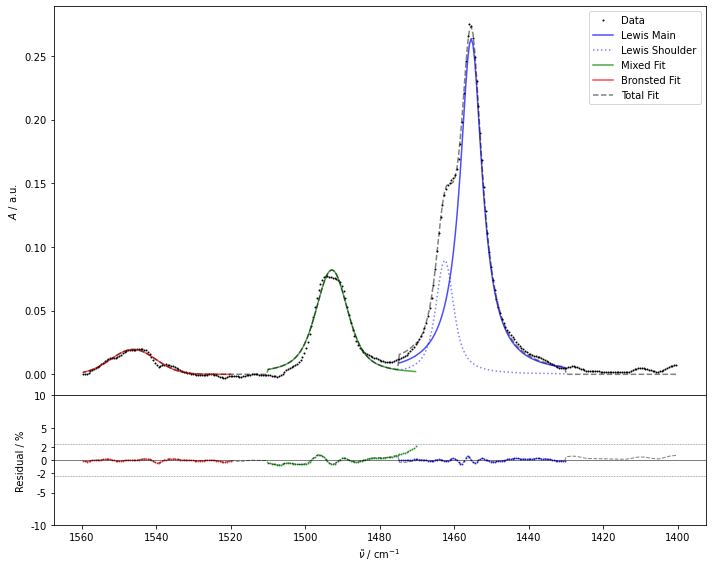

In [31]:
# does the Lewis peak have a shoulder?
shoulder = True #Boolean (True/False)
peak_fitter.force_shoulder("lewis", force=shoulder)

#Run the main analysis
peak_fitter.analyze()

# View results (area, shoulder, detection)
print(peak_fitter.print_results())
peak_fitter.plot_results(index=index)

---
Finally, with the data obtained from the Gaussians, calculate the number of active sites (in $\mu mol \cdot g^{-1}$) by providing the `sample_mass` in $g$ and the `abs_coeff` (absorption coefficent) in $cm \cdot \mu mol^{-1}$.

In [32]:
# Calculate number of acid sites
n_sites = peak_fitter.calc_n_sites()
print("\nCalculated number of acid sites (mmol/g):")
print(f"Bronsted sites: {n_sites[0]:.3f} +/- {n_sites[1]} \u03BCmol/g")
print(f"Lewis sites: {n_sites[2]:.3f} +/- {n_sites[3]} \u03BCmol/g")

# save results to existing json
peak_fitter.update_json(json_filename=f"{data_handling.folder}.json", index=index)


Starting acid site calculation...
Using metadata: {'mass': {'value': 0.1072, 'error': 0.0001, 'unit': 'g'}, 'length': {'value': 2.015, 'error': 0.001, 'unit': 'cm'}, 'width': {'value': 1.013, 'error': 0.001, 'unit': 'cm'}, 'extinction_coefficient': {'bronsted': {'value': 2.22, 'unit': 'mmol cm^-2'}, 'lewis': {'value': 1.67, 'unit': 'mmol cm^-2'}}, 'surface_area': {'value': 351.0, 'error': 0, 'unit': 'm²/g'}}

Using values:
Sample area: 2.0412 ± 0.0023 cm²
Sample mass: 0.1072 ± 0.0001 g
Lewis area: 2.6753
Bronsted area: 0.2913
Extinction coefficient (Lewis): 1.6700
Extinction coefficient (Bronsted): 2.2200

Stored acid sites in results:
Bronsted: 2.4982 ± 0.0036 μmol/g
Lewis: 30.5037 ± 0.0441 μmol/g

Stored site density in results:
Bronsted: 4.2861 ± 0.0062 sites/nm²
Lewis: 52.3343 ± 0.0757 sites/nm²

Stored μmol/nm² in results:
Bronsted: 0.0000 ± 0.0000 μmol/nm²
Lewis: 0.0000 ± 0.0000 μmol/nm²

Results:
Bronsted acid sites: 2.4982 ± 0.0036 μmol/g
Lewis acid sites: 30.5037 ± 0.0441 μmo